# **SPECTRA-CQ Phase 4: Multi-Sensor Training and Convergence (MSE)**
This notebook executes the training phase of the 6-sensor spatial fusion ablation study. We train the pure Classical Autoencoder (CAE) and four Variational Quantum Circuit (VQC) topologies across 3 deterministic seeds to evaluate mathematical convergence and stability (Validation MSE).

*Note: Optimized weights are saved directly to Google Drive at each improving epoch to protect against Colab runtime disconnections.*

*Note: Run this training file on T4 GPU runtime on Colab*

In [ ]:
from google.colab import drive
import os
import sys

# Mount Data Drive
drive.mount('/content/drive')

# Clone Github Repository
GITHUB_TOKEN = "PAT"
REPO_URL = f"https://{GITHUB_TOKEN}@github.com/yeshapan/SPECTRA-CQ.git"

!git clone {REPO_URL}
%cd SPECTRA-CQ
!pip install -r requirements.txt

Mounted at /content/drive
Cloning into 'SPECTRA-CQ'...
remote: Enumerating objects: 348, done.
remote: Counting objects: 100% (275/275), done.
remote: Compressing objects: 100% (177/177), done.
remote: Total 348 (delta 123), reused 230 (delta 79), pack-reused 73 (from 1)
Receiving objects: 100% (348/348), 35.15 MiB | 33.02 MiB/s, done.
Resolving deltas: 100% (133/133), done.
/content/SPECTRA-CQ
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.

In [ ]:
# Hardware Verification
import torch

if torch.cuda.is_available():
    print(f"Hardware Accelerator Confirmed: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    print("FATAL WARNING: GPU not detected. The training protocol will take exponentially longer on a CPU.")
    print("Please navigate to Runtime > Change runtime type > T4 GPU.")

Hardware Accelerator Confirmed: Tesla T4
CUDA Version: 12.8


*NOTE: The 13.97 GB dataset of multi-sensor matrices must be extracted from the Google Drive network mount
directly to the Colab instance's local high-speed NVMe disk to prevent I/O starvation and GPU bottlenecking during training.*

*Automatically aligned the nested path created by the Linux zip utility to match the YAML configuration expectations.*

In [ ]:
import sys
import glob

sys.path.append(os.path.abspath('.'))

# Transfer multi-channel dataset to local NVMe
DRIVE_ARCHIVE_PATH = "/content/drive/MyDrive/spectra-cq-data/spectra_matrices_6ch.zip"
LOCAL_DATA_DIR = "/content/local_spectra_data"
EXPECTED_DIR = f"{LOCAL_DATA_DIR}/processed_spectrograms_6ch"

os.makedirs(LOCAL_DATA_DIR, exist_ok=True)
print("Extracting multi-sensor tensors to local NVMe. This may take a few minutes..")
!unzip -q {DRIVE_ARCHIVE_PATH} -d {LOCAL_DATA_DIR}

# Align the directory structure if the Linux zip nested the folders
extracted_files = glob.glob(f"{LOCAL_DATA_DIR}/**/*.npy", recursive=True)
if extracted_files:
    actual_dir = os.path.dirname(extracted_files[0])
    if actual_dir != EXPECTED_DIR:
        print(f"Aligning nested directory structure from {actual_dir} to {EXPECTED_DIR}..")
        os.makedirs(EXPECTED_DIR, exist_ok=True)
        !mv {actual_dir}/* {EXPECTED_DIR}/
        !rm -rf {LOCAL_DATA_DIR}/content

print("Extraction and path alignment complete. Ready for training loops.")

Extracting multi-sensor tensors to local NVMe. This may take a few minutes..
Aligning nested directory structure from /content/local_spectra_data/content/processed_spectrograms_6ch to /content/local_spectra_data/processed_spectrograms_6ch..
Extraction and path alignment complete. Ready for training loops.


## **Experiment 1: Classical Convolutional Autoencoder (Baseline)**

The CAE processes the 6-channel structural tensors through a weight-tied Siamese convolutional encoder $\rightarrow$ compressing the macroscopic physical dynamics down to a rigid 12-dimensional bottleneck.
This verifies if standard dense mathematical bottlenecks can preserve cross-sensor correlation without collapsing into overfitting.

In [ ]:
os.makedirs("logs", exist_ok=True)
!python scripts/run_experiment.py --config configs/phase4_baseline_cae.yaml | tee /content/drive/MyDrive/spectra-cq-data/logs/phase4_cae.log

2026-07-01 06:59:36,467 - INFO - Compute device allocated: cuda
2026-07-01 06:59:36,468 - INFO - Starting Protocol Run | Seed: 42
2026-07-01 06:59:36,471 - INFO - System locked to deterministic seed: 42
2026-07-01 06:59:36,963 - INFO - Instantiating Classical Autoencoder (CAE)..
2026-07-01 06:59:43,029 - INFO - Initiating training on cuda for 15 epochs.
2026-07-01 07:01:17,753 - INFO - Epoch 1/15 | Train MSE: 0.088658 | Val MSE: 0.021150 | LR: 1.00e-03
2026-07-01 07:01:17,821 - INFO - New optimal weights saved. Validation Loss: 0.021150
2026-07-01 07:02:58,512 - INFO - Epoch 2/15 | Train MSE: 0.015775 | Val MSE: 0.010253 | LR: 1.00e-03
2026-07-01 07:02:58,534 - INFO - New optimal weights saved. Validation Loss: 0.010253
2026-07-01 07:04:41,283 - INFO - Epoch 3/15 | Train MSE: 0.010158 | Val MSE: 0.009632 | LR: 1.00e-03
2026-07-01 07:04:41,306 - INFO - New optimal weights saved. Validation Loss: 0.009632
2026-07-01 07:06:22,736 - INFO - Epoch 4/15 | Train MSE: 0.009659 | Val MSE: 0.0095

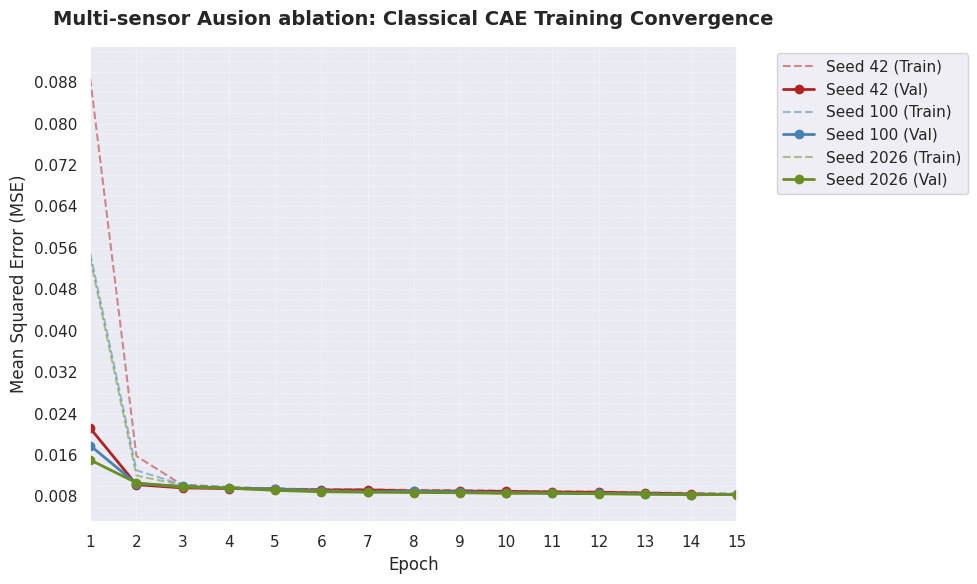

In [ ]:
from src.utils.viz import plot_training_logs

# Ensure Drive is mounted and the path matches your upload location
DRIVE_LOGS = "/content/drive/MyDrive/spectra-cq-data/logs"
Y_LIMITS = (0.003, 0.095)

plot_training_logs(f"{DRIVE_LOGS}/phase4_cae.log", title="Multi-sensor Ausion ablation: Classical CAE Training Convergence", y_lim=Y_LIMITS)

## **Experiment 2: HQAE : Unentangled (`none`) Topology**

This configuration replaces the classical dense layer with 12 isolated, unentangled qubits. The circuit applies strict independent $R_x$ rotations. This acts as a mathematical control group to prove whether quantum cross-talk (entanglement) is actually necessary to map spatial mechanics or if isolated angular parameterization is sufficient.

In [ ]:
!python scripts/run_experiment.py --config configs/phase4_hqae_ablation_none.yaml | tee /content/drive/MyDrive/spectra-cq-data/logs/phase4_none.log

2026-07-02 04:11:14,635 - INFO - Compute device allocated: cuda
2026-07-02 04:11:14,635 - INFO - Starting Protocol Run | Seed: 42
2026-07-02 04:11:14,638 - INFO - System locked to deterministic seed: 42
2026-07-02 04:11:14,700 - INFO - Instantiating Hybrid Quantum Autoencoder (HQAE)..
2026-07-02 04:11:21,166 - INFO - Initiating training on cuda for 15 epochs.
2026-07-02 04:14:57,225 - INFO - Epoch 1/15 | Train MSE: 0.094421 | Val MSE: 0.027768 | LR: 1.00e-03
2026-07-02 04:14:57,260 - INFO - New optimal weights saved. Validation Loss: 0.027768
2026-07-02 04:18:30,281 - INFO - Epoch 2/15 | Train MSE: 0.020927 | Val MSE: 0.018765 | LR: 1.00e-03
2026-07-02 04:18:30,330 - INFO - New optimal weights saved. Validation Loss: 0.018765
2026-07-02 04:22:07,983 - INFO - Epoch 3/15 | Train MSE: 0.018478 | Val MSE: 0.018095 | LR: 1.00e-03
2026-07-02 04:22:08,023 - INFO - New optimal weights saved. Validation Loss: 0.018095
2026-07-02 04:25:45,499 - INFO - Epoch 4/15 | Train MSE: 0.018180 | Val MSE: 

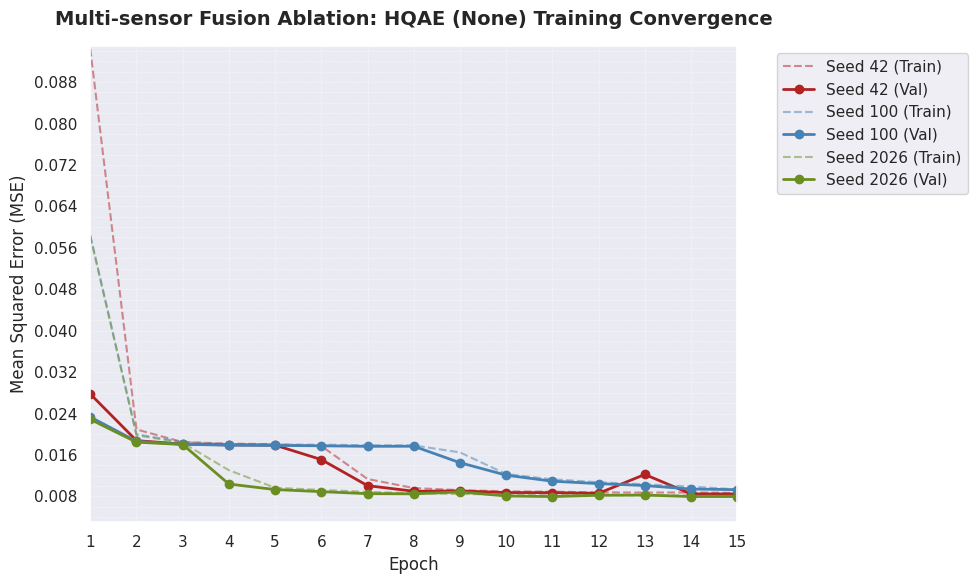

In [ ]:
from src.utils.viz import plot_training_logs
DRIVE_LOGS = "/content/drive/MyDrive/spectra-cq-data/logs"
Y_LIMITS = (0.003, 0.095)

plot_training_logs(f"{DRIVE_LOGS}/phase4_none.log", title="Multi-sensor Fusion Ablation: HQAE (None) Training Convergence", y_lim=Y_LIMITS)

## **Experiment 3: HQAE : All-to-All (`strong`) Entanglement**

This topology utilizes PennyLane's StronglyEntanglingLayers. It enforces all-to-all CNOT gate pairings (every sensor communicates with every other sensor uniformly).

In [ ]:
!python -u scripts/run_experiment.py --config configs/phase4_hqae_ablation_strong.yaml 2>&1 | tee /content/drive/MyDrive/spectra-cq-data/logs/phase4_strong.log

2026-07-01 13:47:35,651 - INFO - Compute device allocated: cuda
2026-07-01 13:47:35,651 - INFO - Starting Protocol Run | Seed: 42
2026-07-01 13:47:35,656 - INFO - System locked to deterministic seed: 42
2026-07-01 13:47:35,698 - INFO - Instantiating Hybrid Quantum Autoencoder (HQAE)..
2026-07-01 13:47:37,977 - INFO - Initiating training on cuda for 15 epochs.
2026-07-01 13:51:19,908 - INFO - Epoch 1/15 | Train MSE: 0.094302 | Val MSE: 0.028282 | LR: 1.00e-03
2026-07-01 13:51:19,941 - INFO - New optimal weights saved. Validation Loss: 0.028282
2026-07-01 13:55:01,425 - INFO - Epoch 2/15 | Train MSE: 0.021329 | Val MSE: 0.019219 | LR: 1.00e-03
2026-07-01 13:55:01,462 - INFO - New optimal weights saved. Validation Loss: 0.019219
2026-07-01 13:58:46,235 - INFO - Epoch 3/15 | Train MSE: 0.018751 | Val MSE: 0.018485 | LR: 1.00e-03
2026-07-01 13:58:46,265 - INFO - New optimal weights saved. Validation Loss: 0.018485
2026-07-01 14:02:30,852 - INFO - Epoch 4/15 | Train MSE: 0.018382 | Val MSE: 

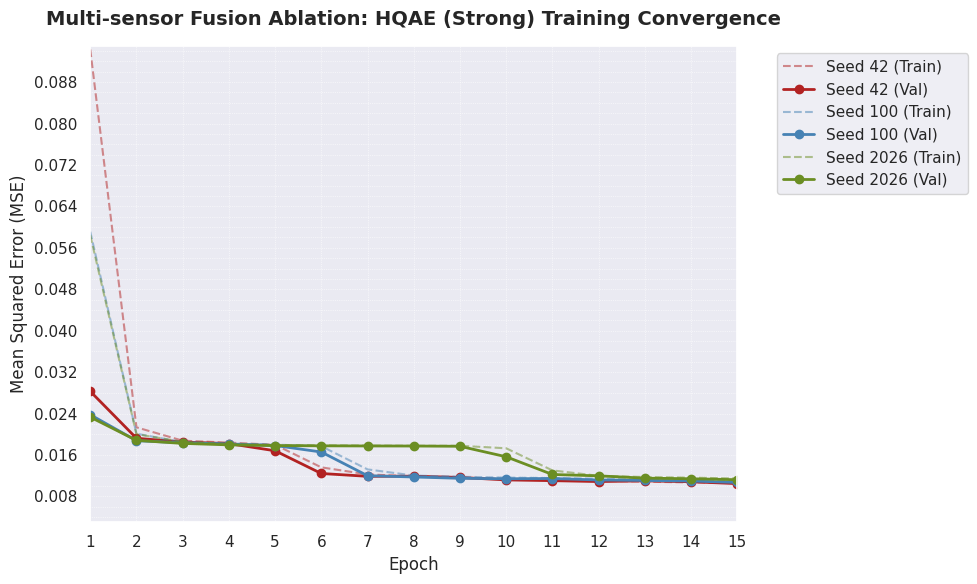

In [ ]:
from src.utils.viz import plot_training_logs
DRIVE_LOGS = "/content/drive/MyDrive/spectra-cq-data/logs"
Y_LIMITS = (0.003, 0.095)

plot_training_logs(f"{DRIVE_LOGS}/phase4_strong.log", title="Multi-sensor Fusion Ablation: HQAE (Strong) Training Convergence", y_lim=Y_LIMITS)